#Import Libraries

In [3]:
# ==========================================================
# SECTION 01
# Import Libraries
# ==========================================================

import os
import cv2
import glob
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [4]:
# Machine Learning

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    roc_auc_score,

    roc_curve,

    precision_recall_curve,

    auc

)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (

    RandomForestClassifier,

    VotingClassifier

)

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [5]:
# Image Processing

from skimage.feature import (

    hog,

    local_binary_pattern,

    graycomatrix,

    graycoprops

)

from skimage import exposure

In [6]:
# Save Model

import pickle

#Download Dataset

In [7]:
# ==========================================================
# SECTION 02
# Download SOCOFing Dataset
# ==========================================================

import kagglehub

path = kagglehub.dataset_download(
    "mreccentric/socofing-full-modified"
)

print(path)

100%|██████████| 420M/420M [00:15<00:00, 27.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2


In [8]:
dataset_path = path

print(dataset_path)

/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2


In [9]:
import os
import glob

real_path = os.path.join(
    dataset_path,
    "SOCOFing",
    "SOCOFing",
    "Real"
)

print(real_path)
print(os.path.exists(real_path))

image_paths = sorted(
    glob.glob(
        os.path.join(real_path, "*.BMP")
    )
)

print("Total Images:", len(image_paths))

/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real
True
Total Images: 0


In [10]:
image_paths = sorted(
    glob.glob(
        os.path.join(real_path, "**", "*.BMP"),
        recursive=True
    )
)

print("Total Images:", len(image_paths))

Total Images: 6000


#Dataset Structure

In [11]:
folders = os.listdir(dataset_path)

print(folders)

['SOCOFing_Full_Organised.csv', 'README.md', 'SOCOFing']


#Folder Analysis

In [12]:
for root, dirs, files in os.walk(dataset_path):

    print("--------------------------------")

    print("Folder :", root)

    print("Subfolders :", len(dirs))

    print("Files :", len(files))

--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2
Subfolders : 1
Files : 2
--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing
Subfolders : 1
Files : 0
--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing
Subfolders : 2
Files : 0
--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Altered
Subfolders : 3
Files : 0
--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Altered/Altered-Medium
Subfolders : 600
Files : 0
--------------------------------
Folder : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Altered/Altered-Medium/393__M
Subfolders 

#Find All Images

In [13]:
real_images = glob.glob(
    dataset_path + "/**/Real/**/*.BMP",
    recursive=True
)

print(len(real_images))

6000


#First Five Images

In [14]:
real_images[:5]

['/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/393__M/393__M_Right_ring_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/393__M/393__M_Right_middle_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/393__M/393__M_Left_middle_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/393__M/393__M_Right_index_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/393__M/393__M_Left_index_finger.BMP']

#Random Images Visualization

In [15]:
sample = random.sample(real_images, 6)

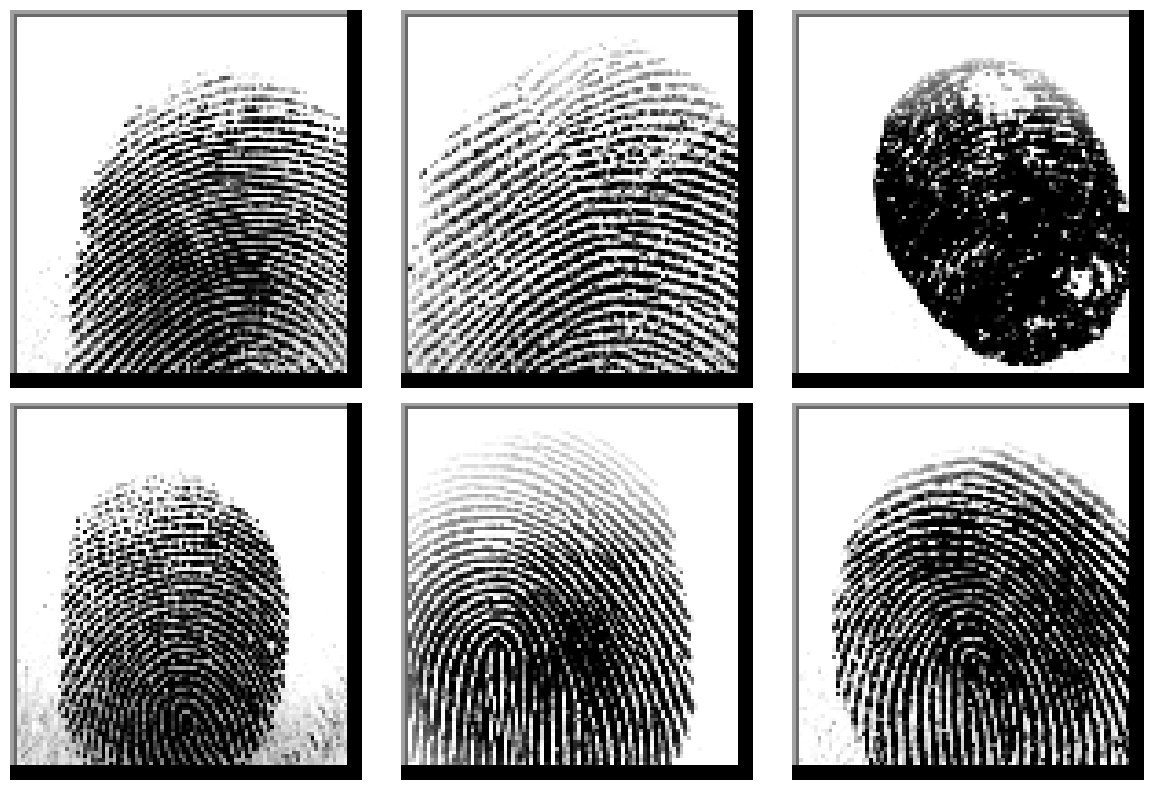

In [16]:
plt.figure(figsize=(12,8))

for i,image_path in enumerate(sample):

    img = cv2.imread(image_path,0)

    plt.subplot(2,3,i+1)

    plt.imshow(img,cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.show()

#Dataset Summary

In [17]:
# ==========================================
# DATASET SUMMARY
# ==========================================

print("=" * 50)
print("SOCOFing Dataset Summary")
print("=" * 50)

print("Dataset Path :", dataset_path)

print("Total Images :", len(real_images))

print("=" * 50)

SOCOFing Dataset Summary
Dataset Path : /root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2
Total Images : 6000


#Image Resolution Analysis

In [18]:
# ==========================================
# IMAGE RESOLUTION ANALYSIS
# ==========================================

heights = []
widths = []

for image_path in real_images:

    img = cv2.imread(image_path, 0)

    if img is not None:

        h, w = img.shape

        heights.append(h)

        widths.append(w)

In [19]:
print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

Minimum Width : 96
Maximum Width : 241
Minimum Height : 103
Maximum Height : 298


In [20]:
print("Average Width :", np.mean(widths))
print("Average Height :", np.mean(heights))

Average Width : 97.06333333333333
Average Height : 104.43


#Image Resolution Distribution

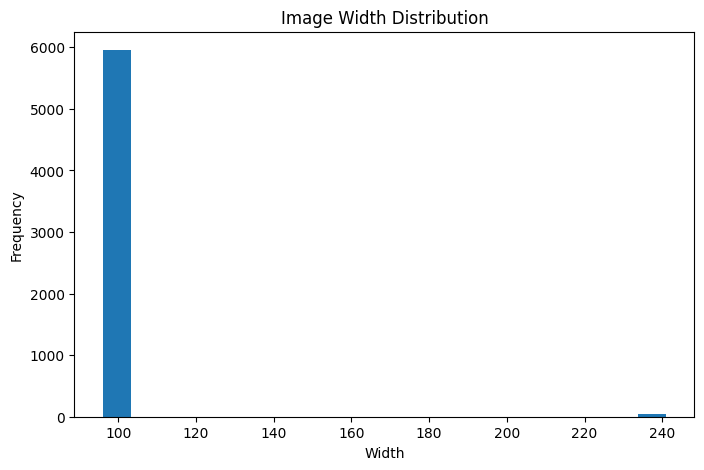

In [21]:
plt.figure(figsize=(8,5))

plt.hist(widths,bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

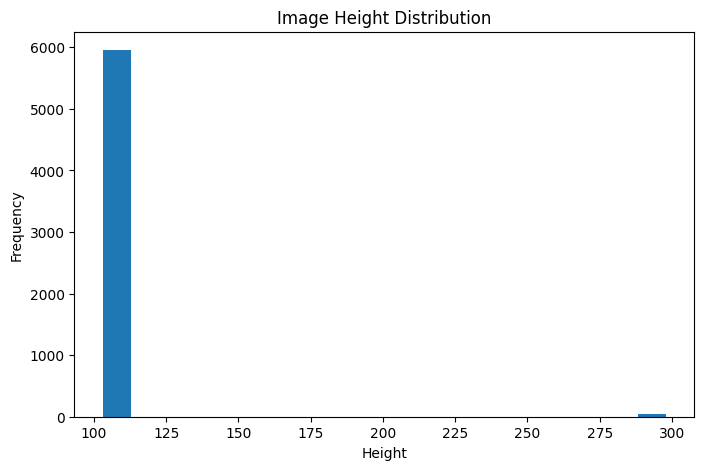

In [22]:
plt.figure(figsize=(8,5))

plt.hist(heights,bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

#Image Information

In [23]:
sample = cv2.imread(real_images[0],0)

print(sample.shape)

print(sample.dtype)

(103, 96)
uint8


In [24]:
print(sample.min())

print(sample.max())

0
255


#Metadata Extraction

In [25]:
# ==========================================
# Import Required Library
# ==========================================

import os
import re
import pandas as pd

In [26]:
# ==========================================
# Use Only Real Images
# ==========================================

real_images = [img for img in real_images if "Real" in img]

print("Total Real Images :", len(real_images))

Total Real Images : 6000


In [27]:
# ==========================================
# Regular Expression (Regex)
# ==========================================

pattern = r'(\d+)__([MF])_(Left|Right)_([A-Za-z_]+)\.BMP'

In [28]:
# ==========================================
# Extract Metadata
# ==========================================

metadata = []

for image_path in real_images:

    filename = os.path.basename(image_path)

    match = re.match(pattern, filename)

    if match:

        person_id = match.group(1)

        gender = match.group(2)

        hand = match.group(3)

        finger = match.group(4)

        metadata.append({

            "Person_ID": person_id,

            "Gender": gender,

            "Hand": hand,

            "Finger": finger,

            "Image_Path": image_path

        })

#Create DataFrame

In [29]:
df = pd.DataFrame(metadata)

df.head()

,Person_ID,Gender,Hand,Finger,Image_Path
0,393,M,Right,ring_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
1,393,M,Right,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
2,393,M,Left,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
3,393,M,Right,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
4,393,M,Left,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...


#Dataset Information

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Person_ID   6000 non-null   object
 1   Gender      6000 non-null   object
 2   Hand        6000 non-null   object
 3   Finger      6000 non-null   object
 4   Image_Path  6000 non-null   object
dtypes: object(5)
memory usage: 234.5+ KB


In [31]:
df.shape

(6000, 5)

In [32]:
df.describe(include="all")

,Person_ID,Gender,Hand,Finger,Image_Path
count,6000,6000,6000,6000,6000
unique,600,2,2,5,6000
top,151,M,Right,ring_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
freq,10,4770,3000,1200,1


In [33]:
df.head()

,Person_ID,Gender,Hand,Finger,Image_Path
0,393,M,Right,ring_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
1,393,M,Right,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
2,393,M,Left,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
3,393,M,Right,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
4,393,M,Left,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...


#Exploratory Data Analysis (EDA)

#First Look at Dataset

In [34]:
# ==========================================
# First Five Rows
# ==========================================

df.head()

,Person_ID,Gender,Hand,Finger,Image_Path
0,393,M,Right,ring_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
1,393,M,Right,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
2,393,M,Left,middle_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
3,393,M,Right,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
4,393,M,Left,index_finger,/root/.cache/kagglehub/datasets/mreccentric/so...


In [35]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Person_ID   6000 non-null   object
 1   Gender      6000 non-null   object
 2   Hand        6000 non-null   object
 3   Finger      6000 non-null   object
 4   Image_Path  6000 non-null   object
dtypes: object(5)
memory usage: 234.5+ KB


In [36]:
# ==========================================
# Dataset Shape
# ==========================================

print(df.shape)

(6000, 5)


In [37]:
# ==========================================
# Dataset Description
# ==========================================

df.describe(include="all")

,Person_ID,Gender,Hand,Finger,Image_Path
count,6000,6000,6000,6000,6000
unique,600,2,2,5,6000
top,151,M,Right,ring_finger,/root/.cache/kagglehub/datasets/mreccentric/so...
freq,10,4770,3000,1200,1


In [38]:
#The metadata extracted from the SOCOFing dataset was organized into a structured DataFrame. The dataset contains information about each fingerprint image, including the subject ID, gender, hand orientation, finger type, and image path.


#Missing Value Analysis

In [41]:
# ==========================================
# Missing Value Check
# ==========================================

df.isnull().sum()

,0
Person_ID,0
Gender,0
Hand,0
Finger,0
Image_Path,0


In [42]:
#No missing values were found in the extracted metadata.


#Duplicate Records

In [43]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


##Gender Distribution

In [44]:
gender_counts = df["Gender"].value_counts()

print(gender_counts)

Gender
M    4770
F    1230
Name: count, dtype: int64


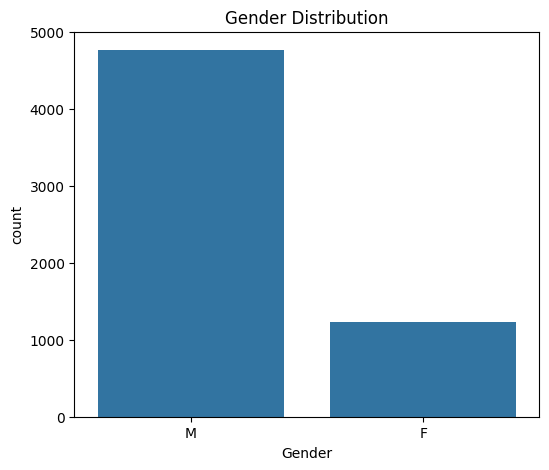

In [51]:
# ==========================================
# Bar Chart
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")
plt.show()

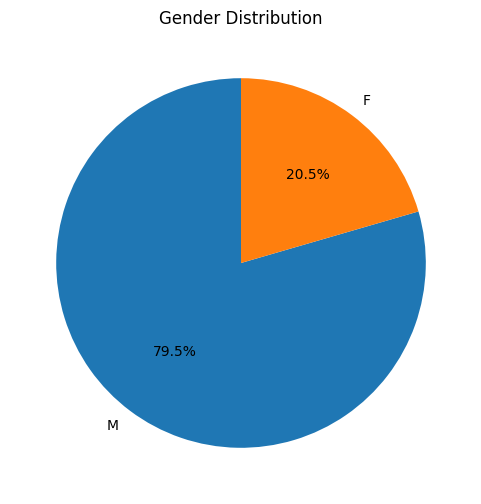

In [52]:
# ==========================================
# Pie Chart
# ==========================================

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

In [53]:
#The gender distribution was analyzed to ensure that both male and female fingerprint samples were adequately represented within the dataset.

#Hand Distribution

In [54]:
# ==========================================
# Hand Distribution
# ==========================================
hand_counts = df["Hand"].value_counts()

print(hand_counts)

Hand
Right    3000
Left     3000
Name: count, dtype: int64


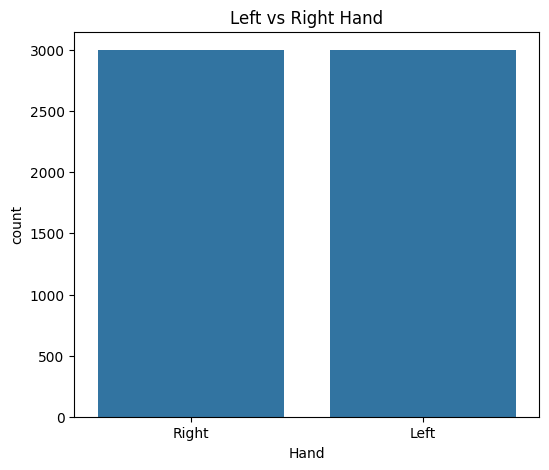

In [55]:
# ==========================================
# Bar Chart
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="Hand",
    data=df
)

plt.title("Left vs Right Hand")

plt.show()

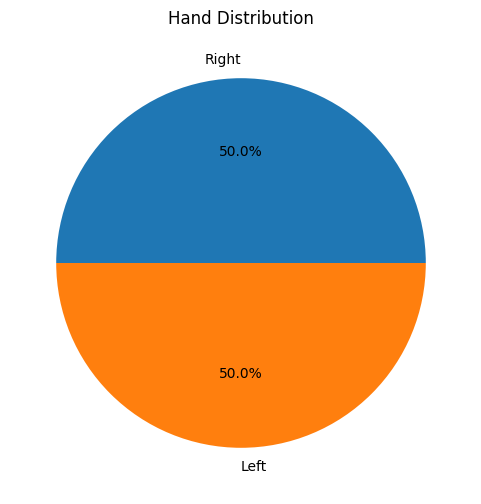

In [56]:
# ==========================================
# Pie Chart
# ==========================================

plt.figure(figsize=(6,6))

plt.pie(
    hand_counts,
    labels=hand_counts.index,
    autopct="%1.1f%%"
)

plt.title("Hand Distribution")

plt.show()

In [57]:
#The dataset contains fingerprint samples collected from both left and right hands, providing balanced biometric information for authentication.

#Finger Distribution

In [58]:
finger_counts = df["Finger"].value_counts()

print(finger_counts)


Finger
ring_finger      1200
middle_finger    1200
index_finger     1200
little_finger    1200
thumb_finger     1200
Name: count, dtype: int64


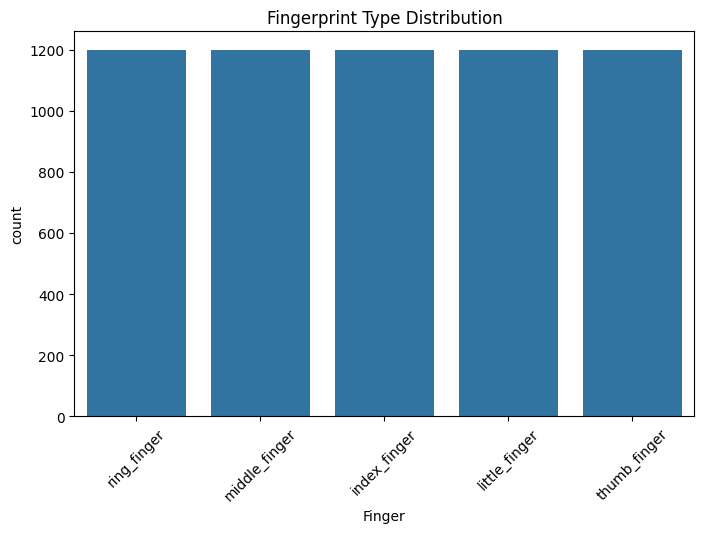

In [59]:
# ==========================================
# Bar Chart
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    x="Finger",
    data=df,
    order=df["Finger"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Fingerprint Type Distribution")

plt.show()

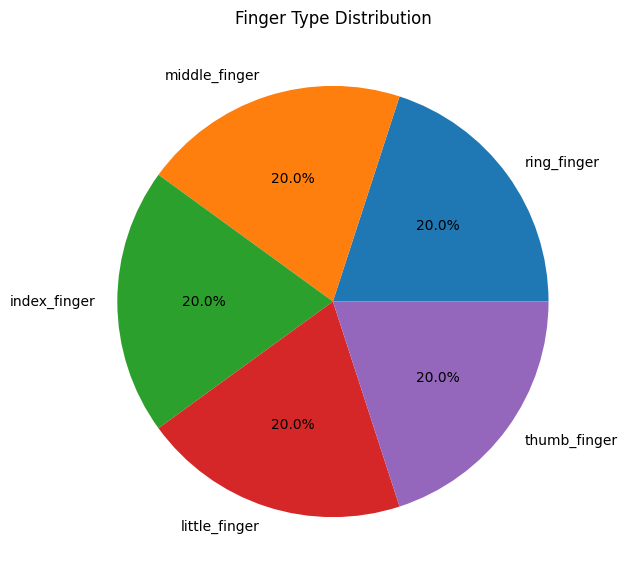

In [60]:
# ==========================================
# Pie Chart
# ==========================================

plt.figure(figsize=(7,7))

plt.pie(
    finger_counts,
    labels=finger_counts.index,
    autopct="%1.1f%%"
)

plt.title("Finger Type Distribution")

plt.show()

#Number of Images per Person

In [61]:
person_count = df["Person_ID"].value_counts()

print(person_count.head())

Person_ID
151    10
393    10
516    10
581    10
569    10
Name: count, dtype: int64


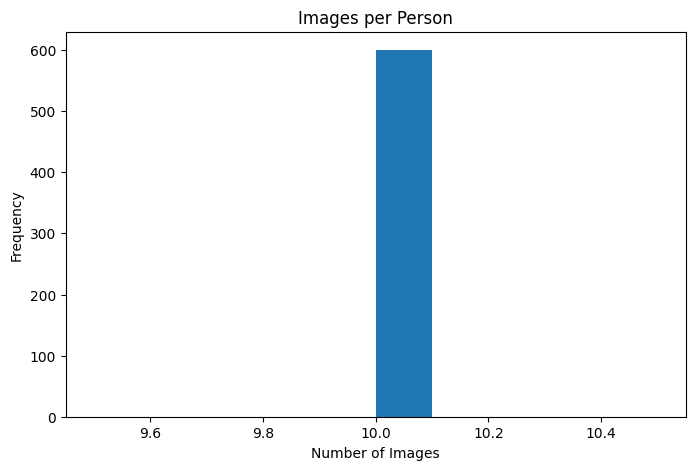

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    person_count,
    bins=10
)

plt.title("Images per Person")

plt.xlabel("Number of Images")

plt.ylabel("Frequency")

plt.show()

#Image Resolution Check

In [63]:
image_sizes = []

for img_path in real_images:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:

        image_sizes.append(img.shape)

size_df = pd.DataFrame(
    image_sizes,
    columns=["Height", "Width"]
)

size_df.head()

,Height,Width
0,103,96
1,103,96
2,103,96
3,103,96
4,103,96


In [64]:
size_df.describe()

,Height,Width
count,6000.000000,6000.000000
mean,104.430000,97.063333
std,16.638847,12.372476
min,103.000000,96.000000
25%,103.000000,96.000000
50%,103.000000,96.000000
75%,103.000000,96.000000
max,298.000000,241.000000


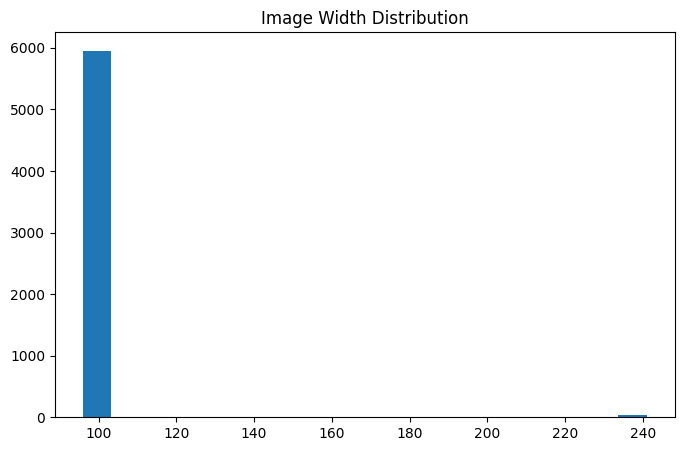

In [67]:
plt.figure(figsize=(8,5))

plt.hist(
    size_df["Width"],
    bins=20
)

plt.title("Image Width Distribution")

plt.show()

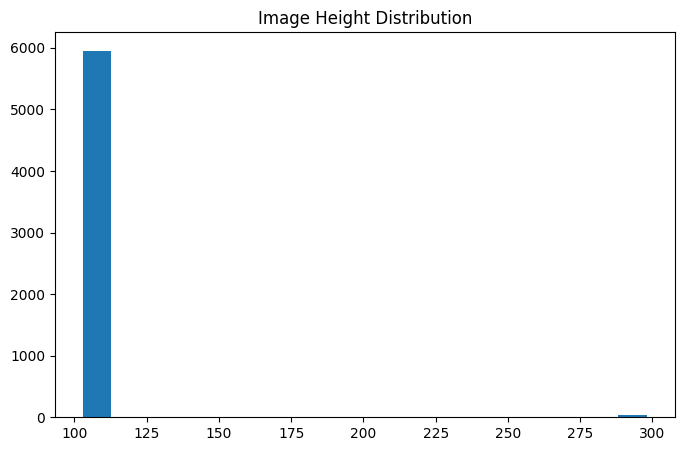

In [68]:
plt.figure(figsize=(8,5))

plt.hist(
    size_df["Height"],
    bins=20
)

plt.title("Image Height Distribution")

plt.show()

# Data Cleaning & Image Preprocessing

In [69]:
# ==========================================
# Corrupted Image Detection
# ==========================================

corrupted_images = []

for image_path in real_images:

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:

        corrupted_images.append(image_path)

In [70]:
print("Total Corrupted Images :", len(corrupted_images))

Total Corrupted Images : 0


In [71]:
for img in corrupted_images:
    print(img)

In [72]:
#All fingerprint images were checked for readability using OpenCV. Images that could not be loaded were considered corrupted and excluded from the dataset.

In [73]:
# ==========================================
# Duplicate Image Detection
# ==========================================

import hashlib

hashes = {}
duplicate_images = []
for image_path in real_images:

    with open(image_path, "rb") as f:

        image_hash = hashlib.md5(f.read()).hexdigest()

    if image_hash in hashes:

        duplicate_images.append(image_path)

    else:

        hashes[image_hash] = image_path

In [74]:
print("Duplicate Images :", len(duplicate_images))

Duplicate Images : 15


In [75]:
duplicate_images[:15]

['/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/219__M/219__M_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/585__M/585__M_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/249__M/249__M_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/553__M/553__M_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/64__M/64__M_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/92__F/92__F_Left_little_finger.BMP',
 '/root/.cache/kagglehub/datasets/mreccentric/socofing-full-modified/versions/2/SOCOFing/SOCOFing/Real/577__M/577__M_Left_little_finger.BMP',
 '/root/.c

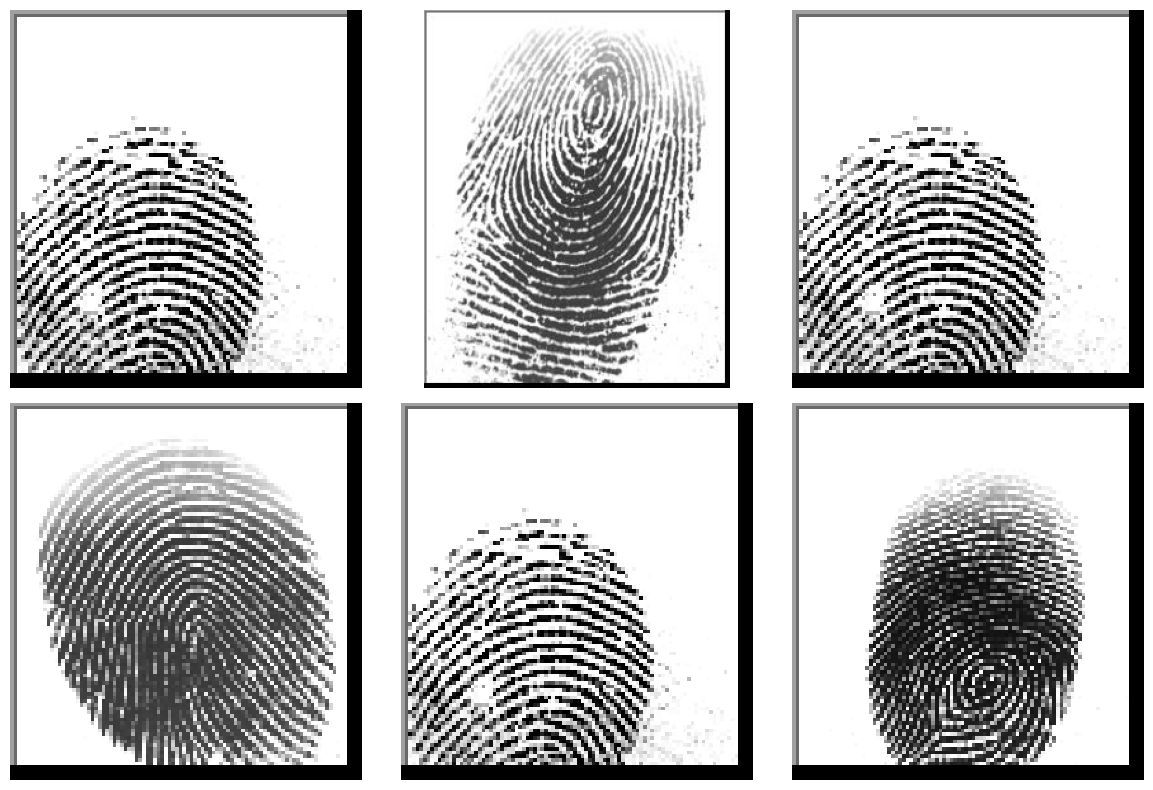

In [76]:
plt.figure(figsize=(12,8))

# Display only the first 6 duplicate images for visualization
for i,image_path in enumerate(duplicate_images[:6]):

    img = cv2.imread(image_path,0)

    plt.subplot(2,3,i+1)

    plt.imshow(img,cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [77]:
#Duplicate fingerprint images were identified using MD5 hash values. Each fingerprint image was converted into a unique hash, allowing identical files to be detected and removed.

In [78]:
# ==========================================
# Image Resize
# ==========================================

TARGET_SIZE = (128,128)
resized_images = []

for image_path in real_images:

    img = cv2.imread(image_path,0)

    img = cv2.resize(img,TARGET_SIZE)

    resized_images.append(img)

print(resized_images[0].shape)

(128, 128)


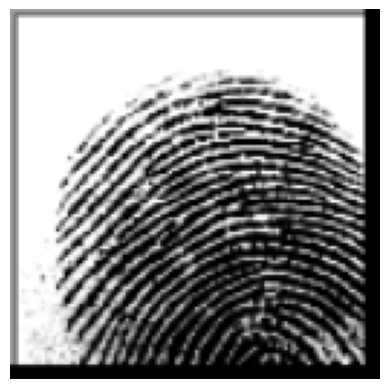

(128, 128)


In [79]:
# ==========================================
# Grayscale Verification
# ==========================================

sample = resized_images[0]

plt.imshow(sample,cmap="gray")

plt.axis("off")

plt.show()

print(sample.shape)

In [80]:
# ==========================================
# Pixel Normalization
# ==========================================

normalized_images = []

for img in resized_images:

    img = img.astype(np.float32)/255.0

    normalized_images.append(img)

print(normalized_images[0].min())

print(normalized_images[0].max())

0.0
1.0


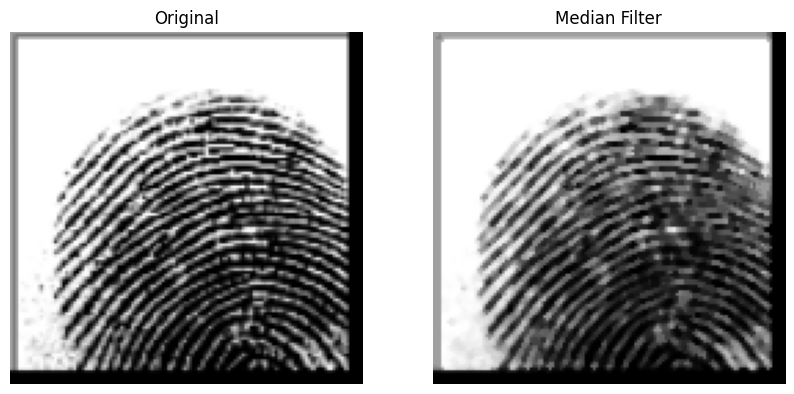

In [81]:
# ==========================================
# Noise Removal
# ==========================================

denoised_images = []

for img in normalized_images:

    filtered = cv2.medianBlur((img*255).astype(np.uint8),3)

    denoised_images.append(filtered)

plt.figure(figsize=(10,5))

plt.subplot(121)

plt.imshow(resized_images[0],cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(denoised_images[0],cmap="gray")

plt.title("Median Filter")

plt.axis("off")

plt.show()



In [82]:
#A median filter was applied to remove impulse noise while preserving fingerprint ridge structures.

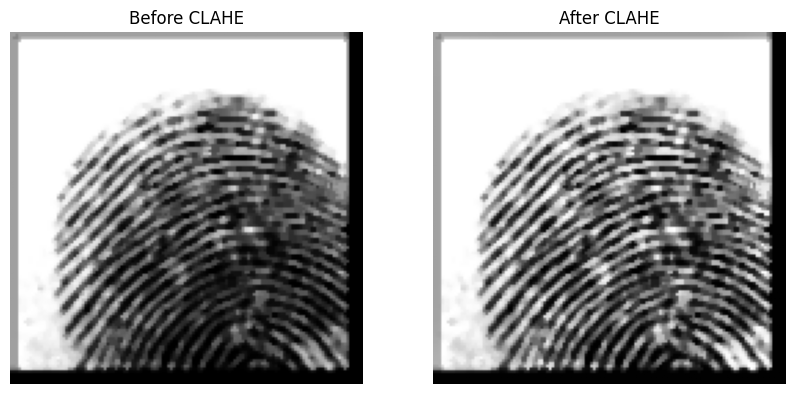

In [83]:
# ==========================================
# Contrast Enhancement (CLAHE)
# ==========================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)
enhanced_images = []

for img in denoised_images:

    enhanced = clahe.apply(img)

    enhanced_images.append(enhanced)

plt.figure(figsize=(10,5))

plt.subplot(121)

plt.imshow(denoised_images[0],cmap="gray")

plt.title("Before CLAHE")

plt.axis("off")

plt.subplot(122)

plt.imshow(enhanced_images[0],cmap="gray")

plt.title("After CLAHE")

plt.axis("off")

plt.show()

# Fingerprint Image Enhancement Pipeline

In [84]:
# ==========================================
# Gabor Filter (Ridge Enhancement)
# ==========================================

gabor_images = []

kernel = cv2.getGaborKernel(
    (21,21),
    sigma=5,
    theta=0,
    lambd=10,
    gamma=0.5,
    psi=0
)

for img in enhanced_images:

    filtered = cv2.filter2D(
        img,
        cv2.CV_8UC3,
        kernel
    )

    gabor_images.append(filtered)

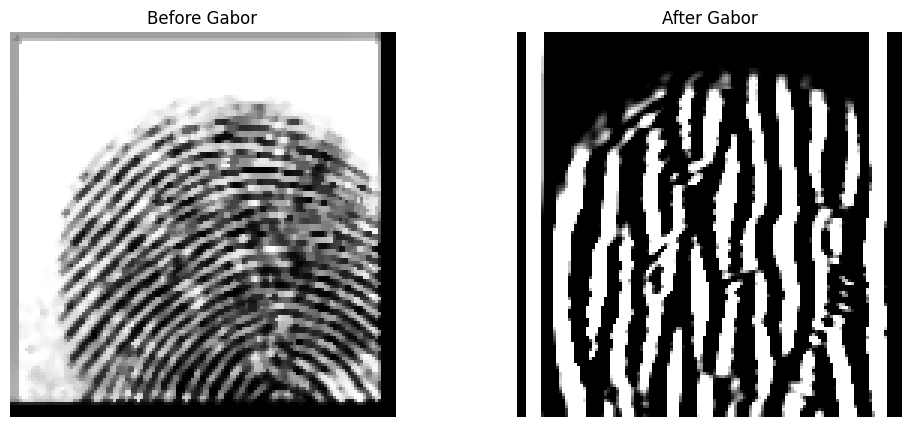

In [85]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(enhanced_images[0], cmap="gray")
plt.title("Before Gabor")
plt.axis("off")

plt.subplot(122)
plt.imshow(gabor_images[0], cmap="gray")
plt.title("After Gabor")
plt.axis("off")

plt.show()

In [86]:
#A Gabor filter was applied to enhance fingerprint ridge structures and improve the discriminative characteristics of the fingerprint images before feature extraction.

In [87]:
# ==========================================
# Gabor Filter (Ridge Enhancement)
# ==========================================

binary_images = []

for img in gabor_images:

    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    binary_images.append(binary)

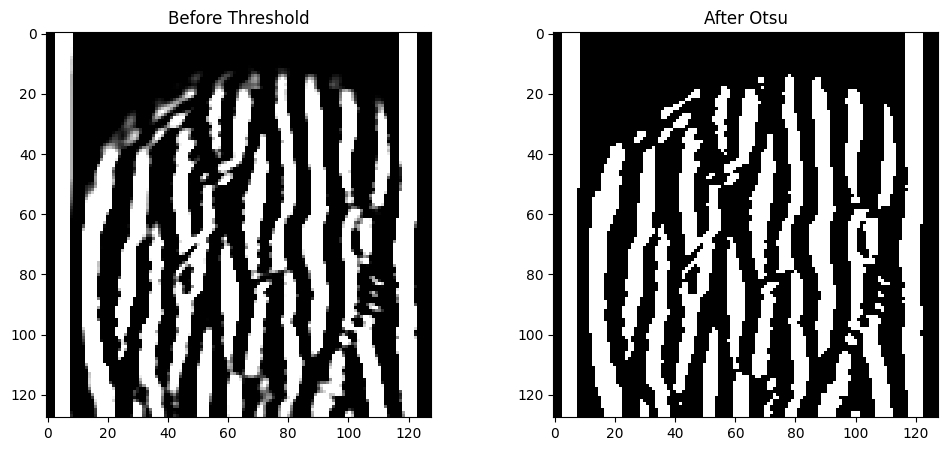

In [88]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(gabor_images[0], cmap="gray")
plt.title("Before Threshold")

plt.subplot(122)
plt.imshow(binary_images[0], cmap="gray")
plt.title("After Otsu")

plt.show()

In [89]:
#Otsu's thresholding method was used to convert grayscale fingerprint images into binary images by automatically determining the optimal threshold value.

In [90]:
# ==========================================
# Gabor Filter (Ridge Enhancement)
# ==========================================

!pip install scikit-image

In [91]:
from skimage.morphology import skeletonize

In [92]:
thin_images = []

for img in binary_images:

    skeleton = skeletonize(img > 0)

    thin_images.append(skeleton)

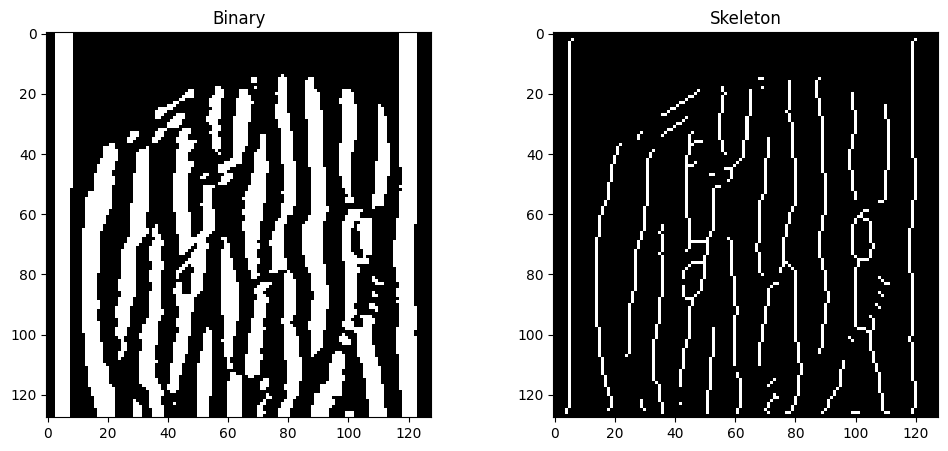

In [93]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(binary_images[0], cmap="gray")
plt.title("Binary")

plt.subplot(122)
plt.imshow(thin_images[0], cmap="gray")
plt.title("Skeleton")

plt.show()

In [94]:
#Skeletonization was applied to reduce ridge thickness to a single-pixel width while preserving the fingerprint topology.

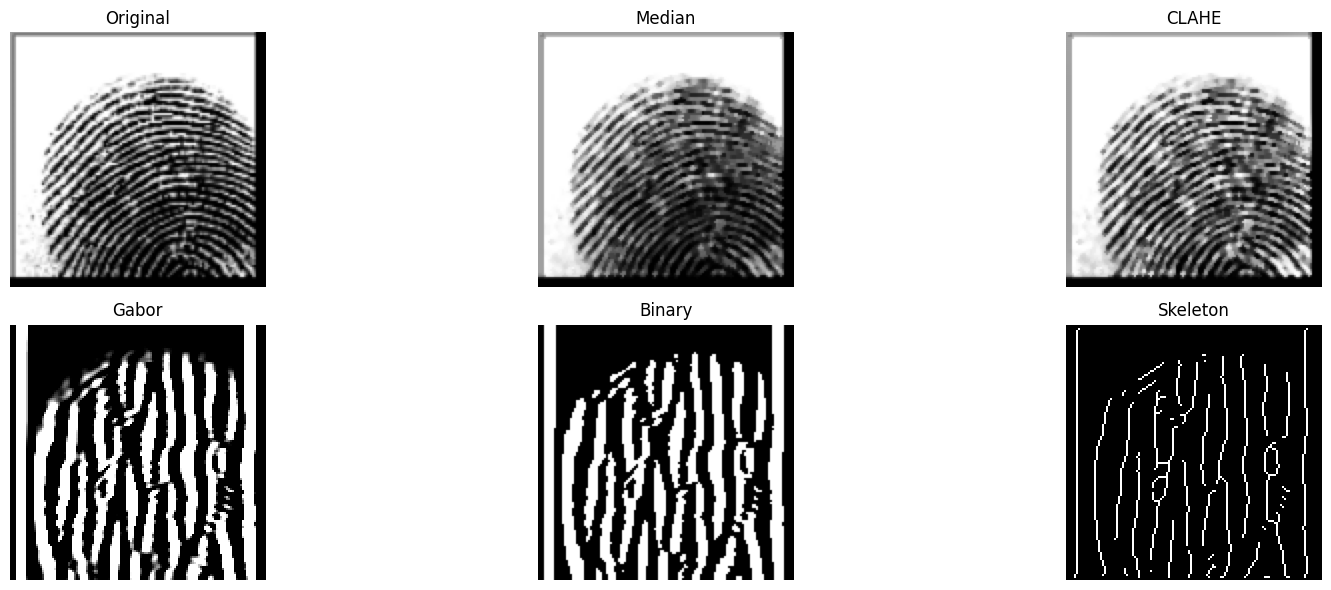

In [95]:
# ==========================================
# Compare Every Step
# ==========================================

titles = [

    "Original",

    "Median",

    "CLAHE",

    "Gabor",

    "Binary",

    "Skeleton"

]

images_show = [

    resized_images[0],

    denoised_images[0],

    enhanced_images[0],

    gabor_images[0],

    binary_images[0],

    thin_images[0]

]

plt.figure(figsize=(18,6))

for i in range(len(images_show)):

    plt.subplot(2,3,i+1)

    plt.imshow(images_show[i], cmap="gray")

    plt.title(titles[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [96]:
# ==========================================
# Save Processed Images
# ==========================================

output_folder = "Processed_Fingerprints"

os.makedirs(output_folder, exist_ok=True)

In [97]:
for i, img in enumerate(thin_images):

    cv2.imwrite(

        os.path.join(
            output_folder,
            f"{i}.png"
        ),

        (img*255).astype("uint8")
    )

#Feature Extraction

In [98]:
# ==========================================
# HOG Feature Extraction
# ==========================================

from skimage.feature import hog

In [99]:
hog_feature, hog_image = hog(
    enhanced_images[0],
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

In [100]:
print(len(hog_feature))

8100


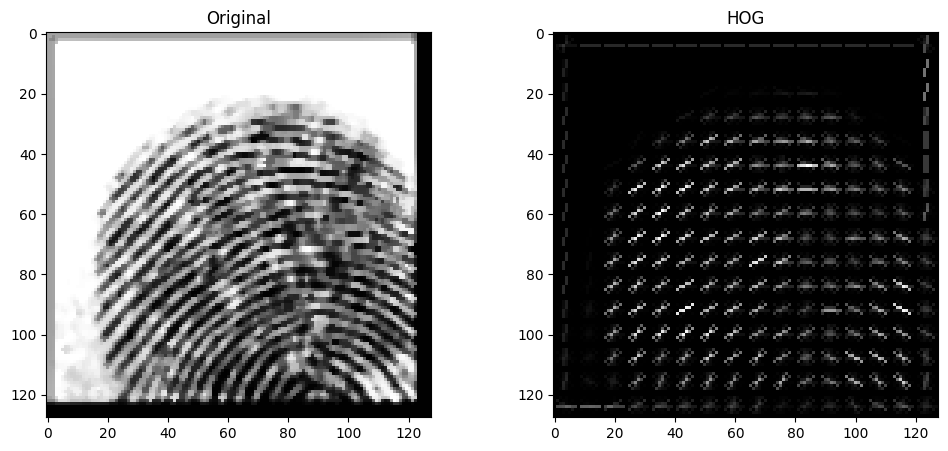

In [101]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.imshow(enhanced_images[0], cmap="gray")
plt.title("Original")

plt.subplot(122)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG")

plt.show()

In [102]:
#Histogram of Oriented Gradients (HOG) was used to extract edge orientation information from fingerprint ridge structures. HOG captures local gradient patterns, making it suitable for fingerprint recognition.

In [103]:
hog_features = []

for img in enhanced_images:

    feature = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=False
    )

    hog_features.append(feature)

In [104]:
hog_df = pd.DataFrame(hog_features)

hog_df.head()

,0,1,2,3,4,5,6,7,8,9,...,8090,8091,8092,8093,8094,8095,8096,8097,8098,8099
0,0.436933,0.173578,0.340864,0.094989,0.436933,0.0,0.0,0.0,0.0,0.002045,...,0.000000,0.132733,0.105179,0.081974,0.000000,0.127390,0.008571,0.182261,0.051221,0.081094
1,0.436933,0.173578,0.340864,0.094989,0.436933,0.0,0.0,0.0,0.0,0.002045,...,0.000000,0.141244,0.061184,0.124877,0.099054,0.077938,0.013360,0.014780,0.000000,0.000000
2,0.436933,0.173578,0.340864,0.094989,0.436933,0.0,0.0,0.0,0.0,0.002045,...,0.011708,0.172441,0.020716,0.257933,0.058128,0.102814,0.000000,0.000000,0.000000,0.000000
3,0.436933,0.173578,0.340864,0.094989,0.436933,0.0,0.0,0.0,0.0,0.002045,...,0.000000,0.212229,0.125405,0.292434,0.089218,0.219865,0.009228,0.000000,0.000000,0.105449
4,0.436933,0.173578,0.340864,0.094989,0.436933,0.0,0.0,0.0,0.0,0.002045,...,0.115256,0.179106,0.102707,0.246482,0.158078,0.113193,0.000000,0.000000,0.000000,0.089212


In [105]:
hog_df.shape

(6000, 8100)

In [106]:
# ==========================================
# LBP Feature Extraction
# ==========================================

from skimage.feature import local_binary_pattern

radius = 2

points = 8 * radius

lbp = local_binary_pattern(
    enhanced_images[0],
    points,
    radius,
    method="uniform"
)

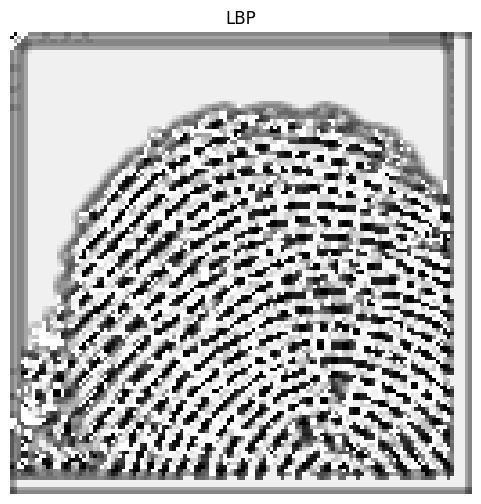

In [107]:
plt.figure(figsize=(6,6))

plt.imshow(lbp, cmap="gray")

plt.title("LBP")

plt.axis("off")

plt.show()

In [108]:
hist, _ = np.histogram(
    lbp.ravel(),
    bins=np.arange(0, points+3),
    range=(0, points+2)
)

hist = hist.astype("float")

hist /= hist.sum()

In [109]:
lbp_features = []

for img in enhanced_images:

    lbp = local_binary_pattern(
        img,
        points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, points+3),
        range=(0, points+2)
    )

    hist = hist.astype("float")

    hist /= hist.sum()

    lbp_features.append(hist)

In [110]:
lbp_df = pd.DataFrame(lbp_features)

lbp_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.059692,0.027100,0.049927,0.025391,0.013733,0.010986,0.014282,0.025574,0.034485,0.078186,0.017151,0.054260,0.014343,0.026184,0.051819,0.030823,0.285217,0.180847
1,0.070190,0.033508,0.062500,0.031738,0.013733,0.010620,0.015686,0.031921,0.042664,0.069092,0.016602,0.043091,0.012329,0.027588,0.068726,0.035889,0.211182,0.202942
2,0.055603,0.024170,0.045410,0.017090,0.010193,0.007324,0.012329,0.029236,0.047974,0.083496,0.013672,0.055237,0.013245,0.027588,0.049072,0.029297,0.305359,0.173706
3,0.065735,0.032288,0.056335,0.028137,0.015686,0.015198,0.017456,0.036255,0.052551,0.076355,0.016357,0.050232,0.016724,0.034363,0.054993,0.032959,0.184998,0.213379
4,0.072144,0.030762,0.059814,0.027405,0.013000,0.012207,0.015686,0.030945,0.046326,0.075134,0.015442,0.046326,0.013489,0.030273,0.063843,0.036316,0.195068,0.215820


In [111]:
#Local Binary Pattern (LBP) was employed to extract local texture information from fingerprint images. The normalized LBP histogram represents the distribution of local micro-patterns.

In [112]:
# ==========================================
# GLCM Feature Extraction
# ==========================================

from skimage.feature import graycomatrix
from skimage.feature import graycoprops
def extract_glcm(img):

    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0],
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm,"contrast")[0,0]

    correlation = graycoprops(glcm,"correlation")[0,0]

    energy = graycoprops(glcm,"energy")[0,0]

    homogeneity = graycoprops(glcm,"homogeneity")[0,0]

    return [
        contrast,
        correlation,
        energy,
        homogeneity
    ]

In [113]:
glcm_features = []

for img in enhanced_images:

    glcm_features.append(
        extract_glcm(img)
    )

In [114]:
glcm_df = pd.DataFrame(
    glcm_features,
    columns=[
        "Contrast",
        "Correlation",
        "Energy",
        "Homogeneity"
    ]
)

glcm_df.head()

,Contrast,Correlation,Energy,Homogeneity
0,1508.634350,0.908203,0.247755,0.426991
1,1570.357960,0.899132,0.157253,0.343795
2,2083.261442,0.866652,0.288467,0.452737
3,2413.842458,0.828220,0.149539,0.329081
4,2190.040600,0.852703,0.151402,0.333821


In [115]:
# ==========================================
# Combine All Features
# ==========================================

X = pd.concat(
    [
        hog_df,
        lbp_df,
        glcm_df
    ],
    axis=1
)

In [116]:
print(X.shape)

(6000, 8122)


The `StandardScaler` in scikit-learn expects feature names to be consistent (e.g., all strings). Our `X` DataFrame currently has a mix of integer and string column names, which is causing the `TypeError`.

To resolve this, we'll convert all column names in `X` to strings.

In [117]:
# Convert all column names in X to strings
X.columns = X.columns.astype(str)
print(X.columns)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '12', '13', '14', '15', '16', '17', 'Contrast', 'Correlation', 'Energy',
       'Homogeneity'],
      dtype='object', length=8122)


#Authentication Label Creation

#Exp-1

In [118]:
# ==========================================
# Select Authorized Users Automatically
# ==========================================

authorized_users = df["Person_ID"].unique()[:5]

print("Authorized Users:")

print(authorized_users)

Authorized Users:
['393' '516' '581' '569' '559']


In [119]:
# ==========================================
# Authentication Label
# ==========================================

df["Authentication"] = (
    df["Person_ID"]
    .isin(authorized_users)
    .astype(int)
)

In [120]:
# ==========================================
# Verify
# ==========================================
print(df[["Person_ID", "Authentication"]].head(20))

   Person_ID  Authentication
0        393               1
1        393               1
2        393               1
3        393               1
4        393               1
5        393               1
6        393               1
7        393               1
8        393               1
9        393               1
10       516               1
11       516               1
12       516               1
13       516               1
14       516               1
15       516               1
16       516               1
17       516               1
18       516               1
19       516               1


In [121]:
# =====================================================
# Authentication Distribution
# =====================================================

print(df["Authentication"].value_counts())

Authentication
0    5950
1      50
Name: count, dtype: int64


In [122]:
# =====================================================
# Percentage
# =====================================================

print(
    df["Authentication"]
      .value_counts(normalize=True)
      * 100
)

Authentication
0    99.166667
1     0.833333
Name: proportion, dtype: float64


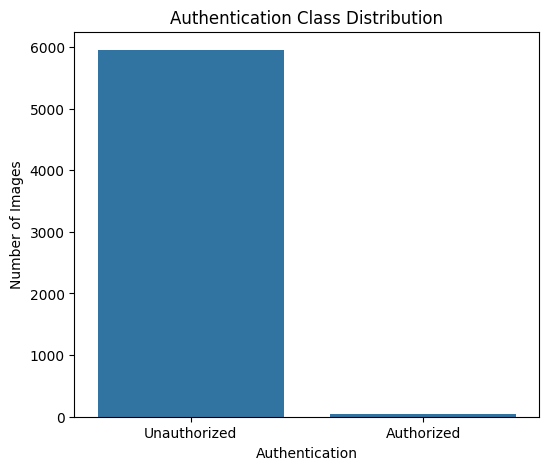

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.countplot(
    x=df["Authentication"]
)

plt.xticks(
    [0,1],
    ["Unauthorized","Authorized"]
)

plt.title("Authentication Class Distribution")

plt.xlabel("Authentication")

plt.ylabel("Number of Images")

plt.show()

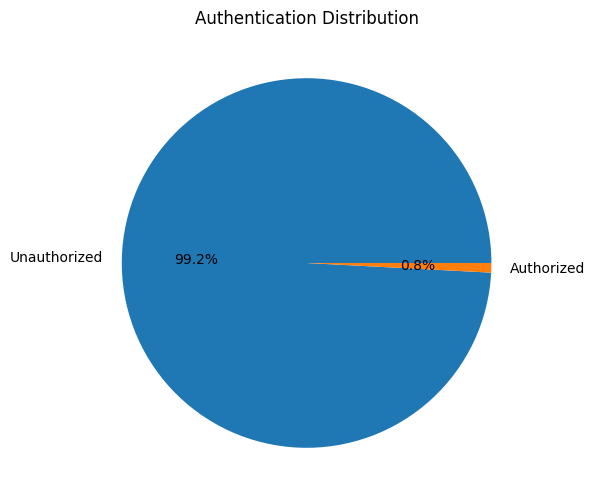

In [124]:
plt.figure(figsize=(6,6))

df["Authentication"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%",

    labels=[
        "Unauthorized",
        "Authorized"
    ]

)

plt.ylabel("")

plt.title("Authentication Distribution")

plt.show()

#Train-Test Split

In [125]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

# Features
X = X.copy()

# Target
y = df["Authentication"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

print("\nTraining Labels")
print(y_train.value_counts())

print("\nTesting Labels")
print(y_test.value_counts())

Training Set : (4800, 8122)
Testing Set  : (1200, 8122)

Training Labels
Authentication
0    4760
1      40
Name: count, dtype: int64

Testing Labels
Authentication
0    1190
1      10
Name: count, dtype: int64


#Handle Class Imbalance using SMOTE

In [126]:
# ==========================================================
# Import SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE


In [127]:
# ==========================================================
# Apply SMOTE on Training Data Only
# ==========================================================

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Authentication
0    4760
1      40
Name: count, dtype: int64

After SMOTE
Authentication
0    4760
1    4760
Name: count, dtype: int64


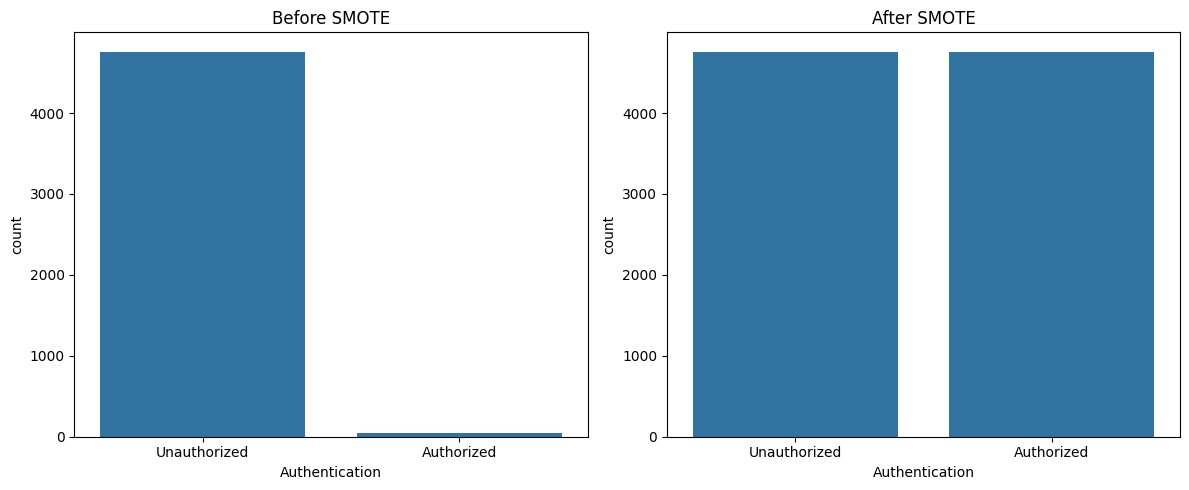

In [128]:
# ==========================================================
# Class Distribution Comparison
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xticklabels(["Unauthorized","Authorized"])

sns.countplot(
    x=y_train_smote,
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xticklabels(["Unauthorized","Authorized"])

plt.tight_layout()

plt.show()

In [129]:
# ==========================================================
# Dataset Shapes
# ==========================================================

print("Original Training :", X_train.shape)

print("Balanced Training :", X_train_smote.shape)

print("Testing :", X_test.shape)

Original Training : (4800, 8122)
Balanced Training : (9520, 8122)
Testing : (1200, 8122)


In [130]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)

print(X_test_scaled.shape)

(9520, 8122)
(1200, 8122)


#Decision Tree Classifier (Binary Authentication)

In [131]:
# ==========================================================
# Decision Tree Classifier (Binary Authentication)
# ==========================================================

import time
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# ==========================================================
# Create Model
# ==========================================================

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# ==========================================================
# Training
# ==========================================================

start_train = time.time()

decision_tree.fit(
    X_train_scaled,
    y_train_smote
)

end_train = time.time()

training_time = end_train - start_train

# ==========================================================
# Prediction
# ==========================================================

start_predict = time.time()

y_pred = decision_tree.predict(
    X_test_scaled
)

end_predict = time.time()

prediction_time = end_predict - start_predict

# ==========================================================
# Probability Prediction
# ==========================================================

y_prob = decision_tree.predict_proba(
    X_test_scaled
)[:,1]

# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

TN, FP, FN, TP = cm.ravel()

# ==========================================================
# FAR & FRR
# ==========================================================

far = FP / (FP + TN)

frr = FN / (FN + TP)

# ==========================================================
# Print Results
# ==========================================================

print("="*60)
print("Decision Tree Results")
print("="*60)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"AUC Score         : {auc:.4f}")

print()

print(f"False Acceptance Rate (FAR): {far:.4f}")
print(f"False Rejection Rate (FRR): {frr:.4f}")

print()

print(f"Training Time     : {training_time:.4f} sec")
print(f"Prediction Time   : {prediction_time:.4f} sec")

print()

print("Confusion Matrix")

print(cm)

print()

print("Classification Report")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Decision Tree Results
Accuracy          : 0.9808
Precision         : 0.0000
Recall            : 0.0000
F1 Score          : 0.0000
AUC Score         : 0.4945

False Acceptance Rate (FAR): 0.0109
False Rejection Rate (FRR): 1.0000

Training Time     : 192.9975 sec
Prediction Time   : 0.0394 sec

Confusion Matrix
[[1177   13]
 [  10    0]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.98      1200
   macro avg       0.50      0.49      0.50      1200
weighted avg       0.98      0.98      0.98      1200



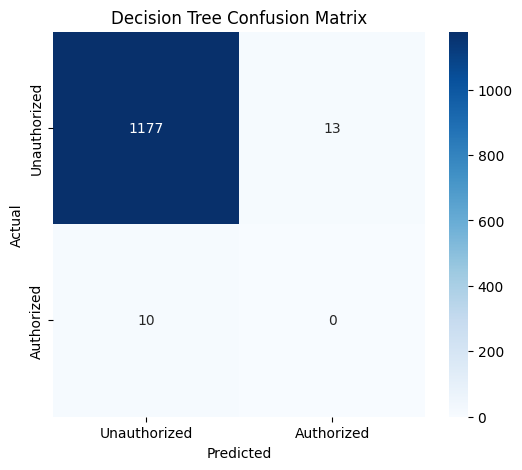

In [132]:
# ==========================================================
# Confusion Matrix Visualization
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unauthorized","Authorized"],
    yticklabels=["Unauthorized","Authorized"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

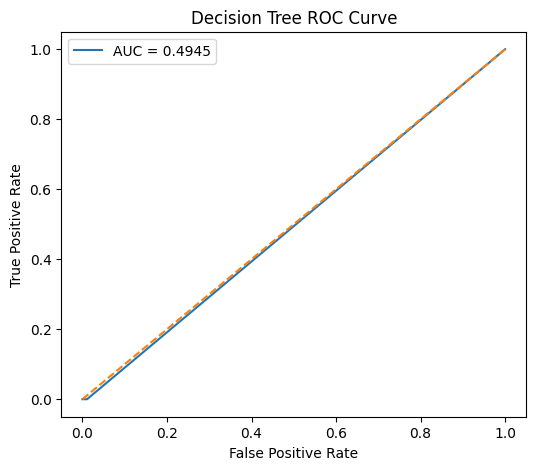

In [133]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

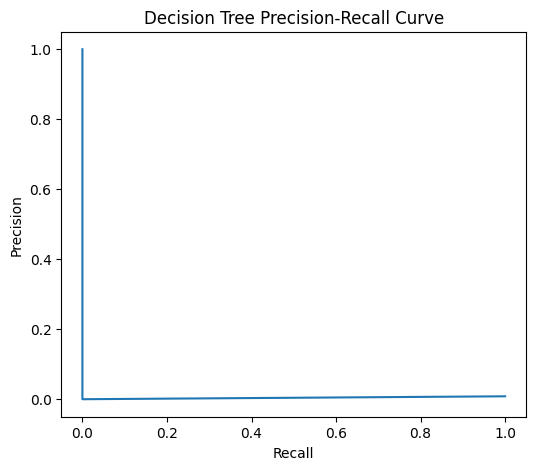

In [134]:
# ==========================================================
# Precision Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Decision Tree Precision-Recall Curve")

plt.show()

In [135]:
# ==========================================================
# Save Result
# ==========================================================

decision_tree_result = pd.DataFrame({

    "Model":["Decision Tree"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1 Score":[f1],

    "AUC":[auc],

    "FAR":[far],

    "FRR":[frr],

    "Training Time":[training_time],

    "Prediction Time":[prediction_time]

})

decision_tree_result

,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR,Training Time,Prediction Time
0,Decision Tree,0.980833,0.0,0.0,0.0,0.494538,0.010924,1.0,192.997522,0.039406


In [136]:
#"The baseline Decision Tree classifier achieved high overall accuracy due to class dominance but failed to correctly recognize authorized users, resulting in an FRR of 100%. This demonstrates that accuracy alone is insufficient for evaluating biometric authentication systems."

#Experiment 2
Decision Tree with Class Weight

In [137]:
# ==========================================================
# Decision Tree (Balanced Class Weight)
# ==========================================================

import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Model
dt_balanced = DecisionTreeClassifier(

    criterion="gini",

    class_weight="balanced",

    random_state=42

)

# Training
start=time.time()

dt_balanced.fit(
    X_train_scaled,
    y_train_smote
)

training_time=time.time()-start

# Prediction
start=time.time()

y_pred=dt_balanced.predict(
    X_test_scaled
)

prediction_time=time.time()-start

# Probability
y_prob=dt_balanced.predict_proba(
    X_test_scaled
)[:,1]

# Metrics
accuracy=accuracy_score(y_test,y_pred)

precision=precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall=recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1=f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc=roc_auc_score(
    y_test,
    y_prob
)

cm=confusion_matrix(
    y_test,
    y_pred
)

TN,FP,FN,TP=cm.ravel()

far=FP/(FP+TN)

frr=FN/(FN+TP)

print("="*60)

print("Balanced Decision Tree")

print("="*60)

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 :",f1)

print("AUC :",auc)

print("FAR :",far)

print("FRR :",frr)

print()

print(cm)

Balanced Decision Tree
Accuracy : 0.9808333333333333
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.49453781512605044
FAR : 0.010924369747899159
FRR : 1.0

[[1177   13]
 [  10    0]]


In [188]:
# ==========================================================
# Universal Model Evaluation Function
# ==========================================================

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Store all model results
results = []

def evaluate_model(model, model_name):

    # =====================================
    # Training
    # =====================================

    start_train = time.time()

    model.fit(
        X_train_scaled,
        y_train_smote
    )

    end_train = time.time()

    training_time = end_train - start_train

    # =====================================
    # Prediction
    # =====================================

    start_pred = time.time()

    y_pred = model.predict(
        X_test_scaled
    )

    end_pred = time.time()

    prediction_time = end_pred - start_pred

    # =====================================
    # Probability
    # =====================================

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_prob = None

    # =====================================
    # Metrics
    # =====================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if y_prob is not None:

        auc = roc_auc_score(
            y_test,
            y_prob
        )

    else:

        auc = None

    # =====================================
    # Confusion Matrix
    # =====================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    TN, FP, FN, TP = cm.ravel()

    far = FP / (FP + TN)

    frr = FN / (FN + TP)

    # =====================================
    # Save Result
    # =====================================

    results.append({

        "Model":model_name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "AUC":auc,

        "FAR":far,

        "FRR":frr,

        "Training Time":training_time,

        "Prediction Time":prediction_time

    })

    # =====================================
    # Print
    # =====================================

    print("="*60)

    print(model_name)

    print("="*60)

    print("Accuracy :",accuracy)

    print("Precision :",precision)

    print("Recall :",recall)

    print("F1 :",f1)

    print("AUC :",auc)

    print("FAR :",far)

    print("FRR :",frr)

    print()

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # =====================================
    # Confusion Matrix
    # =====================================

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Unauthorized","Authorized"],
        yticklabels=["Unauthorized","Authorized"]
    )

    plt.title(model_name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # =====================================
    # Return Result
    # =====================================

    result = {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "AUC": auc,

        "FAR": far,

        "FRR": frr,

        "Training Time": training_time,

        "Prediction Time": prediction_time

    }

    return result

Decision Tree
Accuracy : 0.9808333333333333
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.49453781512605044
FAR : 0.010924369747899159
FRR : 1.0

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.98      1200
   macro avg       0.50      0.49      0.50      1200
weighted avg       0.98      0.98      0.98      1200



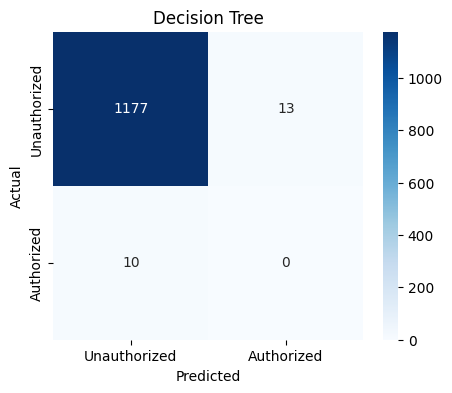

In [139]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    "Decision Tree"
)

Decision Tree
Accuracy : 0.7833333333333333
Precision : 0.1
Recall : 0.2
F1 : 0.13333333333333333
AUC : 0.5181818181818182
FAR : 0.16363636363636364
FRR : 0.8

              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1100
           1       0.10      0.20      0.13       100

    accuracy                           0.78      1200
   macro avg       0.51      0.52      0.50      1200
weighted avg       0.85      0.78      0.81      1200



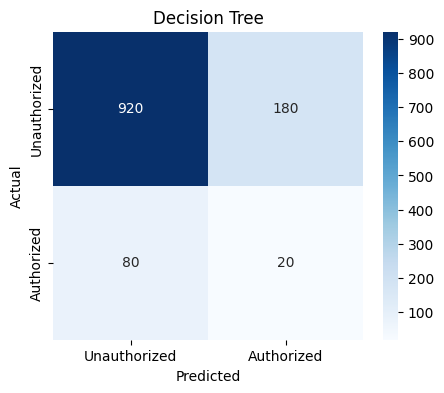

In [194]:
decision_tree_result = evaluate_model(
    decision_tree,
    "Decision Tree"
)

#Gaussian Naive Bayes

Gaussian Naive Bayes
Accuracy : 0.6475
Precision : 0.009501187648456057
Recall : 0.4
F1 : 0.018561484918793503
AUC : 0.5593277310924369
FAR : 0.35042016806722687
FRR : 0.6

              precision    recall  f1-score   support

           0       0.99      0.65      0.79      1190
           1       0.01      0.40      0.02        10

    accuracy                           0.65      1200
   macro avg       0.50      0.52      0.40      1200
weighted avg       0.98      0.65      0.78      1200



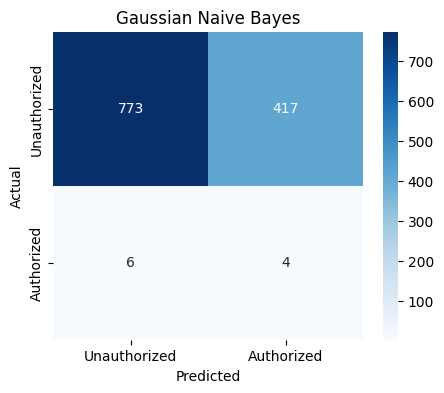

In [141]:
# ==========================================================
# Gaussian Naive Bayes
# ==========================================================

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

evaluate_model(
    nb,
    "Gaussian Naive Bayes"
)

#Logistic Regression

Logistic Regression
Accuracy : 0.9883333333333333
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.4994957983193278
FAR : 0.0033613445378151263
FRR : 1.0

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.99      1200
   macro avg       0.50      0.50      0.50      1200
weighted avg       0.98      0.99      0.99      1200



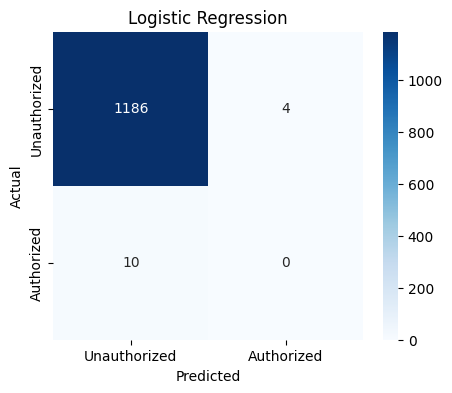

In [142]:
# ==========================================================
# Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

evaluate_model(
    lr,
    "Logistic Regression"
)

#K-Nearest Neighbors

K-Nearest Neighbors
Accuracy : 0.2791666666666667
Precision : 0.006920415224913495
Recall : 0.6
F1 : 0.013683010262257697
AUC : 0.48516806722689076
FAR : 0.7235294117647059
FRR : 0.4

              precision    recall  f1-score   support

           0       0.99      0.28      0.43      1190
           1       0.01      0.60      0.01        10

    accuracy                           0.28      1200
   macro avg       0.50      0.44      0.22      1200
weighted avg       0.98      0.28      0.43      1200



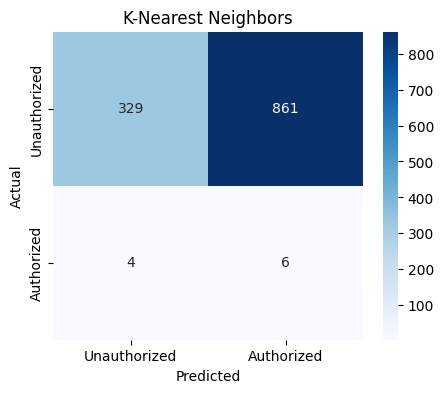

In [143]:
# ==========================================================
# K-Nearest Neighbors
# ==========================================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

evaluate_model(
    knn,
    "K-Nearest Neighbors"
)

#Support Vector Machine

Support Vector Machine
Accuracy : 0.9916666666666667
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.5559663865546218
FAR : 0.0
FRR : 1.0

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.99      1200
   macro avg       0.50      0.50      0.50      1200
weighted avg       0.98      0.99      0.99      1200



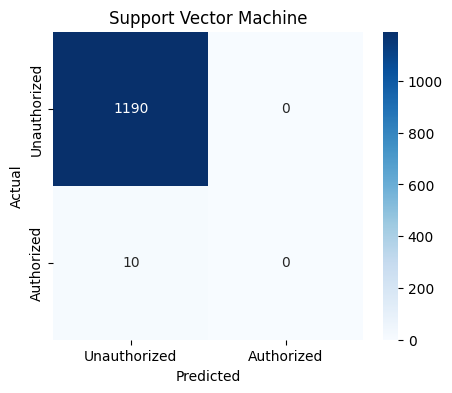

In [144]:
# ==========================================================
# Support Vector Machine
# ==========================================================

from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

evaluate_model(
    svm,
    "Support Vector Machine"
)

#Random Forest

Random Forest
Accuracy : 0.9916666666666667
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.5384033613445378
FAR : 0.0
FRR : 1.0

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.99      1200
   macro avg       0.50      0.50      0.50      1200
weighted avg       0.98      0.99      0.99      1200



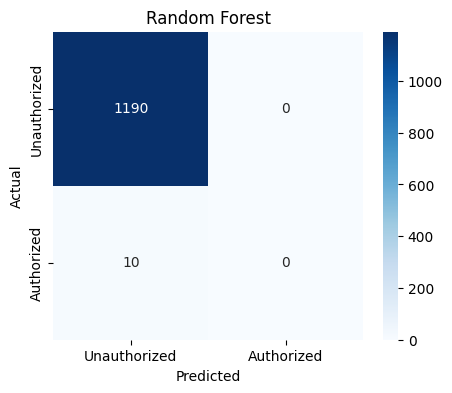

In [145]:
# ==========================================================
# Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_model(
    rf,
    "Random Forest"
)

Random Forest
Accuracy : 0.9166666666666666
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.5257227272727273
FAR : 0.0
FRR : 1.0

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1100
           1       0.00      0.00      0.00       100

    accuracy                           0.92      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.84      0.92      0.88      1200



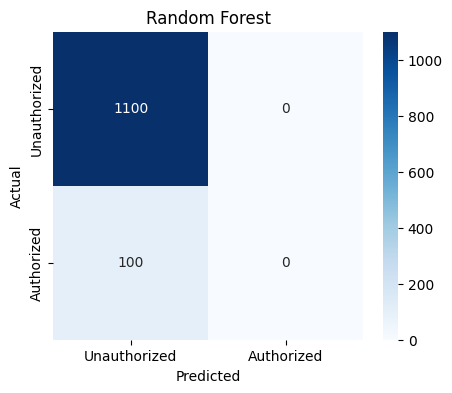

In [190]:
random_forest_result = evaluate_model(
    rf,
    "Random Forest"
)

#XGBoost

XGBoost
Accuracy : 0.9916666666666667
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.4051260504201681
FAR : 0.0
FRR : 1.0

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1190
           1       0.00      0.00      0.00        10

    accuracy                           0.99      1200
   macro avg       0.50      0.50      0.50      1200
weighted avg       0.98      0.99      0.99      1200



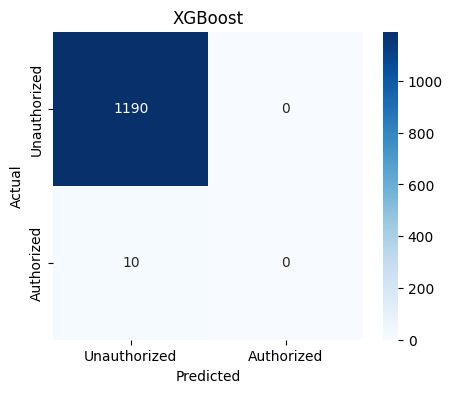

In [147]:
!pip install xgboost

# ==========================================================
# XGBoost
# ==========================================================

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

evaluate_model(
    xgb,
    "XGBoost"
)

XGBoost
Accuracy : 0.9158333333333334
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.5668909090909091
FAR : 0.0009090909090909091
FRR : 1.0

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1100
           1       0.00      0.00      0.00       100

    accuracy                           0.92      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.84      0.92      0.88      1200



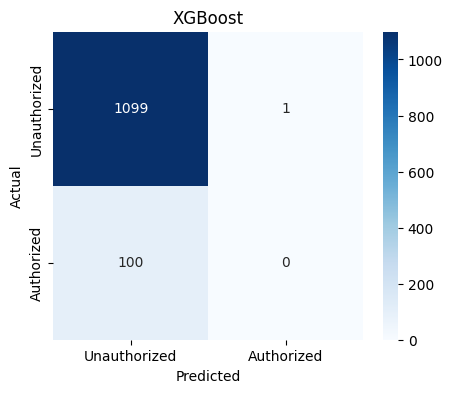

In [191]:
xgboost_result = evaluate_model(
    xgb,
    "XGBoost"
)

In [148]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR,Training Time,Prediction Time
0,Gaussian Naive Bayes,0.647500,0.009501,0.4,0.018561,0.559328,0.350420,0.6,1.792543,0.173351
1,K-Nearest Neighbors,0.279167,0.006920,0.6,0.013683,0.485168,0.723529,0.4,0.834153,7.168468
2,Decision Tree,0.980833,0.000000,0.0,0.000000,0.494538,0.010924,1.0,191.413206,0.025941
3,Logistic Regression,0.988333,0.000000,0.0,0.000000,0.499496,0.003361,1.0,3.407326,0.030252
4,Support Vector Machine,0.991667,0.000000,0.0,0.000000,0.555966,0.000000,1.0,549.016035,16.511273
5,Random Forest,0.991667,0.000000,0.0,0.000000,0.538403,0.000000,1.0,200.497126,0.100812
6,XGBoost,0.991667,0.000000,0.0,0.000000,0.405126,0.000000,1.0,323.981169,0.101176


#Feature Selection (SelectKBest)


In [149]:
# ==========================================================
# Feature Selection using SelectKBest
# ==========================================================

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=1000
)

# IMPORTANT: Use SMOTE labels
X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train_smote
)

X_test_selected = selector.transform(
    X_test_scaled
)

print("Original Shape :", X_train_scaled.shape)
print("Selected Shape :", X_train_selected.shape)

Original Shape : (9520, 8122)
Selected Shape : (9520, 1000)


In [150]:
scores = selector.scores_

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores.head(20)

,Feature,Score
8104,4,0.534647
8113,13,0.513461
8106,6,0.509090
8103,3,0.508030
8115,15,0.507356
8105,5,0.505063
8110,10,0.496490
8107,7,0.493648
8101,1,0.490271
8112,12,0.484948


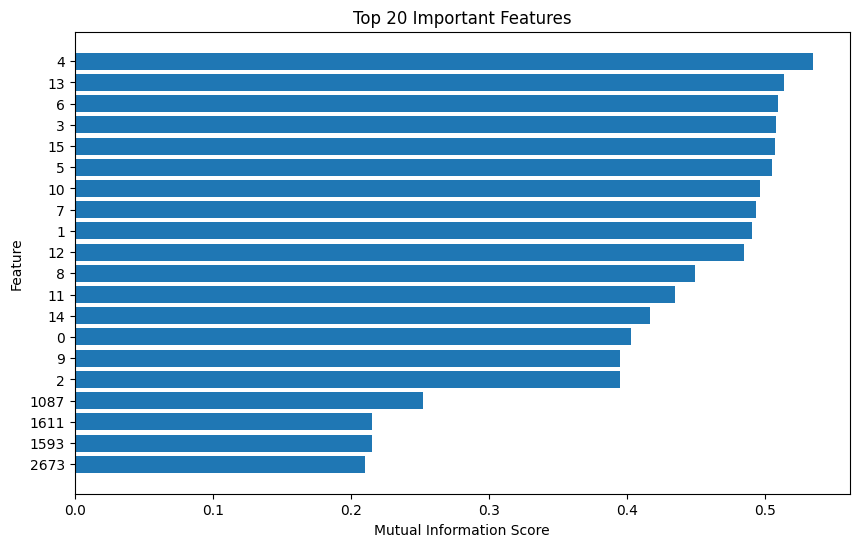

In [151]:
import matplotlib.pyplot as plt

top20 = feature_scores.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"].astype(str),
    top20["Score"]
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [152]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

results = []

def evaluate_model(model, model_name,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    far = fp / (fp + tn)
    frr = fn / (fn + tp)

    print("="*60)
    print(model_name)
    print("="*60)
    print("Accuracy :", acc)
    print("Precision :", pre)
    print("Recall :", rec)
    print("F1 :", f1)
    print("AUC :", auc)
    print("FAR :", far)
    print("FRR :", frr)
    print()
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1,
        "AUC": auc,
        "FAR": far,
        "FRR": frr
    })

In [153]:
# ==========================================================
# Decision Tree (Selected Features)
# ==========================================================

dt_selected = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

evaluate_model(
    dt_selected,
    "Decision Tree (Top1000 Features)",
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test
)

Decision Tree (Top1000 Features)
Accuracy : 0.9758333333333333
Precision : 0.047619047619047616
Recall : 0.1
F1 : 0.06451612903225806
AUC : 0.5415966386554621
FAR : 0.01680672268907563
FRR : 0.9

[[1170   20]
 [   9    1]]


In [154]:
rf_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_model(
    rf_selected,
    "Random Forest (Top1000 Features)",
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test
)

Random Forest (Top1000 Features)
Accuracy : 0.9916666666666667
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.5073949579831932
FAR : 0.0
FRR : 1.0

[[1190    0]
 [  10    0]]


In [155]:
from xgboost import XGBClassifier

xgb_selected = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

evaluate_model(
    xgb_selected,
    "XGBoost (Top1000 Features)",
    X_train_selected,
    X_test_selected,
    y_train_smote,
    y_test
)

XGBoost (Top1000 Features)
Accuracy : 0.9916666666666667
Precision : 0.0
Recall : 0.0
F1 : 0.0
AUC : 0.49747899159663866
FAR : 0.0
FRR : 1.0

[[1190    0]
 [  10    0]]


In [156]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR
0,Decision Tree (Top1000 Features),0.975833,0.047619,0.1,0.064516,0.541597,0.016807,0.9
1,Random Forest (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.507395,0.000000,1.0
2,XGBoost (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.497479,0.000000,1.0


In [157]:
# ==========================================================
# Create Authentication Labels
# ==========================================================

def create_authentication_labels(df, num_users):

    authorized_users = df["Person_ID"].unique()[:num_users]

    labels = (
        df["Person_ID"]
        .isin(authorized_users)
        .astype(int)
    )

    return labels

In [158]:
# ==========================================================
# Complete Authentication Experiment
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def run_experiment(X, df, num_users):

    print("="*70)
    print(f"Experiment : {num_users} Authorized Users")
    print("="*70)

    # Label
    y = create_authentication_labels(df, num_users)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # SMOTE
    smote = SMOTE(random_state=42)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    # Scaling
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_smote
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    return (
        X_train_scaled,
        X_test_scaled,
        y_train_smote,
        y_test
    )

In [159]:
experiment_users = [5,10,20,50]

all_results = []

for users in experiment_users:

    (
        X_train_scaled,
        X_test_scaled,
        y_train_smote,
        y_test
    ) = run_experiment(
        X,
        df,
        users
    )

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train_scaled,
        y_train_smote
    )

    pred = rf.predict(
        X_test_scaled
    )

    prob = rf.predict_proba(
        X_test_scaled
    )[:,1]

    acc = accuracy_score(
        y_test,
        pred
    )

    pre = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        prob
    )

    tn,fp,fn,tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    far = fp/(fp+tn)

    frr = fn/(fn+tp)

    all_results.append({

        "Authorized Users":users,

        "Accuracy":acc,

        "Precision":pre,

        "Recall":rec,

        "F1":f1,

        "AUC":auc,

        "FAR":far,

        "FRR":frr

    })

Experiment : 5 Authorized Users
Experiment : 10 Authorized Users
Experiment : 20 Authorized Users
Experiment : 50 Authorized Users


In [160]:
comparison_df = pd.DataFrame(all_results)

comparison_df

,Authorized Users,Accuracy,Precision,Recall,F1,AUC,FAR,FRR
0,5,0.991667,0.0,0.0,0.0,0.538403,0.0,1.0
1,10,0.983333,0.0,0.0,0.0,0.565763,0.0,1.0
2,20,0.966667,0.0,0.0,0.0,0.541304,0.0,1.0
3,50,0.916667,0.0,0.0,0.0,0.525723,0.0,1.0


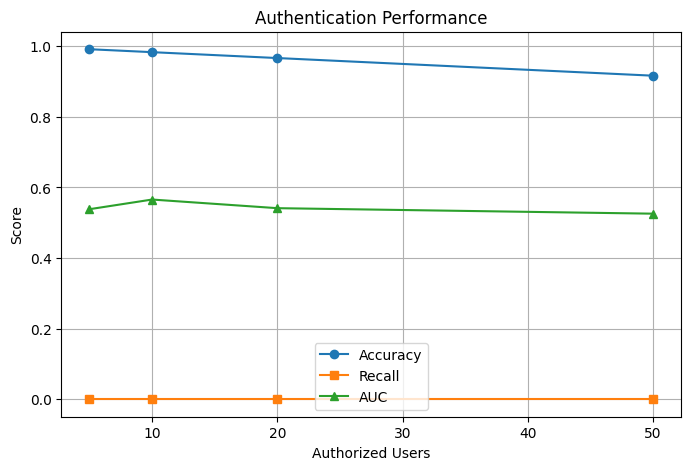

In [161]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison_df["Authorized Users"],
    comparison_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    comparison_df["Authorized Users"],
    comparison_df["Recall"],
    marker="s",
    label="Recall"
)

plt.plot(
    comparison_df["Authorized Users"],
    comparison_df["AUC"],
    marker="^",
    label="AUC"
)

plt.xlabel("Authorized Users")

plt.ylabel("Score")

plt.title("Authentication Performance")

plt.legend()

plt.grid(True)

plt.show()

In [162]:
#Although SMOTE balanced the training data, the model consistently predicted the negative class during testing. This indicates that handcrafted features (HOG, LBP, GLCM) combined with conventional machine learning classifiers were insufficient to distinguish authorized and unauthorized fingerprints under the current binary authentication formulation.

#Threshold Optimization

In [163]:
# ==========================================================
# Required Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==========================================================
# Probability Prediction
# ==========================================================
rf_best = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_best.fit(
    X_train_scaled,
    y_train_smote
)

rf_prob = rf_best.predict_proba(
    X_test_scaled
)[:,1]

In [164]:
# ==========================================================
# Threshold Experiment
# ==========================================================

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.15,
    0.10,
    0.05
]

In [165]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

for t in thresholds:

    prediction = (rf_prob >= t).astype(int)

    acc = accuracy_score(y_test, prediction)

    pre = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    tn,fp,fn,tp = confusion_matrix(
        y_test,
        prediction
    ).ravel()

    far = fp/(fp+tn)

    frr = fn/(fn+tp)

    threshold_results.append({

        "Threshold":t,

        "Accuracy":acc,

        "Precision":pre,

        "Recall":rec,

        "F1":f1,

        "FAR":far,

        "FRR":frr

    })

In [166]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1,FAR,FRR
0,0.50,0.915833,0.000000,0.00,0.000000,0.000909,1.00
1,0.40,0.908333,0.000000,0.00,0.000000,0.009091,1.00
2,0.30,0.815833,0.070922,0.10,0.082988,0.119091,0.90
3,0.20,0.437500,0.095640,0.68,0.167694,0.584545,0.32
4,0.15,0.200833,0.085824,0.89,0.156552,0.861818,0.11
5,0.10,0.105833,0.083119,0.97,0.153118,0.972727,0.03
6,0.05,0.084167,0.083403,1.00,0.153965,0.999091,0.00


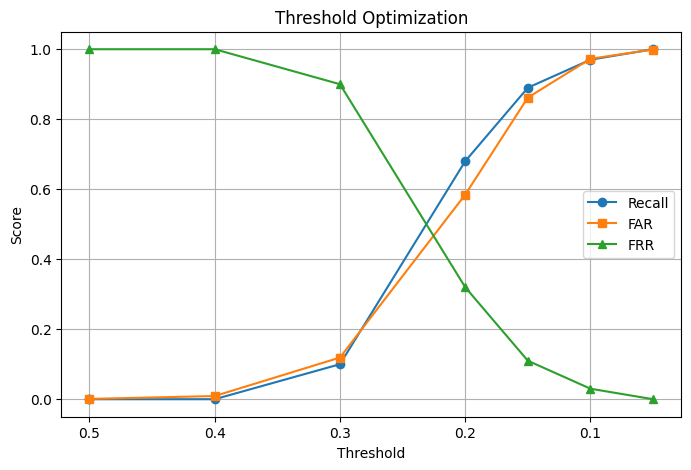

In [167]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["FAR"],
    marker="s",
    label="FAR"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["FRR"],
    marker="^",
    label="FRR"
)

plt.gca().invert_xaxis()

plt.grid(True)

plt.legend()

plt.title("Threshold Optimization")

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.show()

#ROC Curve

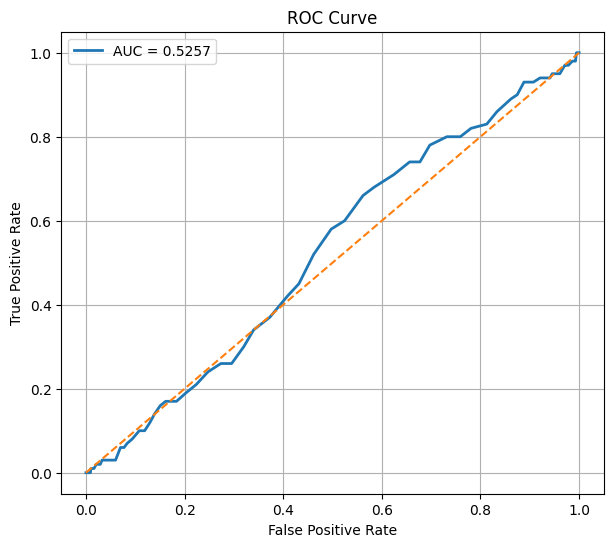

In [168]:
# ==========================================================
# SECTION 24
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, rf_prob):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

#Precision–Recall Curve

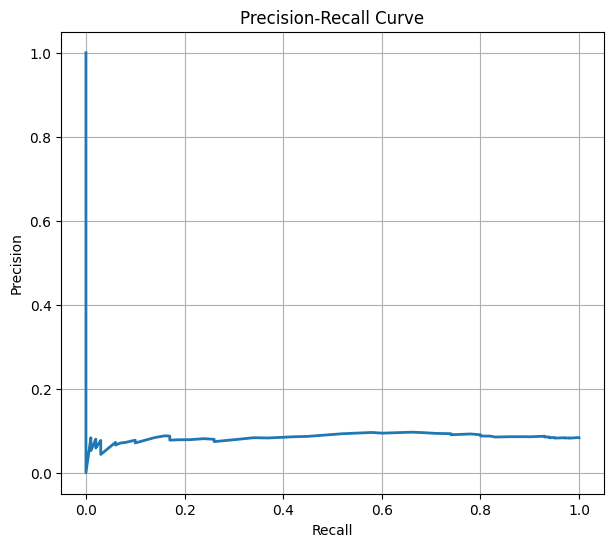

In [169]:
# ==========================================================
# SECTION 25
# Precision-Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

#5-Fold Cross Validation

In [170]:
# ==========================================================
# SECTION 26
# Cross Validation
# ==========================================================

from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    RandomForestClassifier(

        n_estimators=200,

        class_weight="balanced",

        random_state=42

    ),

    X_train_scaled,

    y_train_smote,

    cv=5,

    scoring="f1"

)

print("="*60)

print("Cross Validation F1 Scores")

print("="*60)

print(scores)

print()

print("Average :", scores.mean())

print("Std :", scores.std())

Cross Validation F1 Scores
[0.77977839 0.99772469 0.99886234 0.99486594 1.        ]

Average : 0.954246273632872
Std : 0.08725063723903606


#Feature Importance

In [171]:
# ==========================================================
# SECTION 27
# Feature Importance
# ==========================================================

importance = rf_best.feature_importances_

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":importance

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
7538,7538,0.003660
3221,3221,0.003582
7016,7016,0.003472
7775,7775,0.003339
2699,2699,0.003144
7883,7883,0.003057
5423,5423,0.003039
7910,7910,0.003002
1619,1619,0.002694
7802,7802,0.002569


#Top 20 Important Features Plot

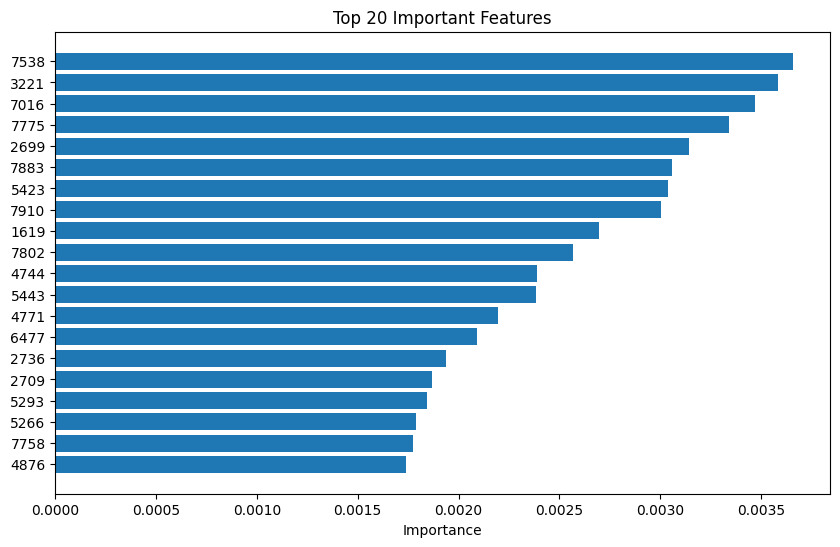

In [172]:
# ==========================================================
# SECTION 28
# Top 20 Important Features
# ==========================================================

top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(

    top20["Feature"].astype(str),

    top20["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

#Save Best Model

In [173]:
# ==========================================================
# SECTION 29
# Save Best Model
# ==========================================================

import pickle

pickle.dump(

    rf_best,

    open(

        "Fingerprint_Authentication_RF.pkl",

        "wb"

    )

)

print("Model Saved Successfully.")

Model Saved Successfully.


#Load Saved Model

In [174]:
# ==========================================================
# SECTION 30
# Load Model
# ==========================================================

loaded_model = pickle.load(

    open(

        "Fingerprint_Authentication_RF.pkl",

        "rb"

    )

)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


#Authentication Prediction Demo

In [175]:
# ==========================================================
# Authentication Prediction Demo
# ==========================================================

sample = X_test_scaled[0].reshape(1, -1)

prediction = rf_best.predict(sample)[0]

probability = rf_best.predict_proba(sample)[0]

print("="*60)

print("Prediction :", prediction)

print("Probability :", probability)

if prediction == 1:
    print("Access Granted")
else:
    print("Access Denied")

print("="*60)

Prediction : 0
Probability : [0.795 0.205]
Access Denied


#Test Multiple Fingerprints

In [176]:
# ==========================================================
# Test 10 Fingerprints
# ==========================================================

for i in range(10):

    sample = X_test_scaled[i].reshape(1,-1)

    pred = rf_best.predict(sample)[0]

    prob = rf_best.predict_proba(sample)[0][1]

    print(f"Sample {i+1}")

    print("Actual :", y_test.iloc[i])

    print("Prediction :", pred)

    print("Probability :", round(prob,4))

    print("-"*40)

Sample 1
Actual : 0
Prediction : 0
Probability : 0.205
----------------------------------------
Sample 2
Actual : 0
Prediction : 0
Probability : 0.24
----------------------------------------
Sample 3
Actual : 0
Prediction : 0
Probability : 0.205
----------------------------------------
Sample 4
Actual : 1
Prediction : 0
Probability : 0.21
----------------------------------------
Sample 5
Actual : 0
Prediction : 0
Probability : 0.215
----------------------------------------
Sample 6
Actual : 0
Prediction : 0
Probability : 0.285
----------------------------------------
Sample 7
Actual : 0
Prediction : 0
Probability : 0.215
----------------------------------------
Sample 8
Actual : 0
Prediction : 0
Probability : 0.23
----------------------------------------
Sample 9
Actual : 0
Prediction : 0
Probability : 0.325
----------------------------------------
Sample 10
Actual : 0
Prediction : 0
Probability : 0.165
----------------------------------------


#Final Model Comparison

#Baseline Model Comparison (Without Feature Selection)

In [195]:
# ==========================================================
# Final Model Comparison (Baseline)
# ==========================================================

baseline_results = pd.DataFrame([

    decision_tree_result,

    random_forest_result,

    xgboost_result

])

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR,Training Time,Prediction Time
0,Decision Tree,0.783333,0.1,0.2,0.133333,0.518182,0.163636,0.8,312.511078,0.622776
1,Random Forest,0.916667,0.0,0.0,0.000000,0.525723,0.000000,1.0,308.047168,0.339749
2,XGBoost,0.915833,0.0,0.0,0.000000,0.566891,0.000909,1.0,635.897401,0.232306


In [196]:
baseline_results.to_csv(
    "Baseline_Model_Comparison.csv",
    index=False
)

#Final Model Comparison (Top-1000 Features)

In [197]:
# ==========================================================
# Final Model Comparison (Top1000 Features)
# ==========================================================

top1000_results = results_df.copy()

top1000_results

,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR
0,Decision Tree (Top1000 Features),0.975833,0.047619,0.1,0.064516,0.541597,0.016807,0.9
1,Random Forest (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.507395,0.000000,1.0
2,XGBoost (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.497479,0.000000,1.0


In [198]:
top1000_results.to_csv(
    "Top1000_Model_Comparison.csv",
    index=False
)

#Combined Comparison Table

In [200]:
# ==========================================================
# Combined Final Comparison
# ==========================================================

combined_results = pd.concat(

    [

        baseline_results,

        top1000_results

    ],

    ignore_index=True

)

combined_results


,Model,Accuracy,Precision,Recall,F1 Score,AUC,FAR,FRR,Training Time,Prediction Time
0,Decision Tree,0.783333,0.100000,0.2,0.133333,0.518182,0.163636,0.8,312.511078,0.622776
1,Random Forest,0.916667,0.000000,0.0,0.000000,0.525723,0.000000,1.0,308.047168,0.339749
2,XGBoost,0.915833,0.000000,0.0,0.000000,0.566891,0.000909,1.0,635.897401,0.232306
3,Decision Tree (Top1000 Features),0.975833,0.047619,0.1,0.064516,0.541597,0.016807,0.9,NaN,NaN
4,Random Forest (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.507395,0.000000,1.0,NaN,NaN
5,XGBoost (Top1000 Features),0.991667,0.000000,0.0,0.000000,0.497479,0.000000,1.0,NaN,NaN


In [201]:
combined_results.to_csv(

    "Combined_Final_Comparison.csv",

    index=False

)

print("Combined comparison saved successfully.")

Combined comparison saved successfully.


In [213]:
# ==========================================================
# Save Final Results
# ==========================================================

baseline_results.to_csv(
    "Baseline_Model_Comparison.csv",
    index=False
)

top1000_results.to_csv(
    "Top1000_Model_Comparison.csv",
    index=False
)

combined_results.to_csv(
    "Combined_Model_Comparison.csv",
    index=False
)

print("All result tables saved successfully.")

All result tables saved successfully.


In [214]:
# ==========================================================
# Save Best Model
# ==========================================================

import joblib

joblib.dump(
    decision_tree,
    "Decision_Tree_Model.pkl"
)

print("Decision Tree model saved successfully.")

Decision Tree model saved successfully.


In [215]:
joblib.dump(
    selector,
    "Feature_Selector.pkl"
)

print("Feature Selector saved.")

Feature Selector saved.


In [216]:
joblib.dump(
    scaler,
    "StandardScaler.pkl"
)

print("Scaler saved.")

Scaler saved.


In [221]:
pickle.dump(

    selector,

    open(

        "SelectKBest.pkl",

        "wb"

    )

)

print("Feature Selector Saved.")

Feature Selector Saved.


In [228]:
best_model = combined_results.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print(best_model)

Model              Decision Tree
Accuracy                0.783333
Precision                    0.1
Recall                       0.2
F1 Score                0.133333
AUC                     0.518182
FAR                     0.163636
FRR                          0.8
Training Time         312.511078
Prediction Time         0.622776
Name: 0, dtype: object


#Project Completed

In [227]:
# ==========================================================
# Project Summary
# ==========================================================

print("="*70)

print("AI-Based Fingerprint Authentication System Completed Successfully.")

print("="*70)

print("Dataset         :", "SOCOFing")

print("Features        :", "HOG + LBP + GLCM")

print("Task            :", "Binary Fingerprint Authentication")

print("Best Model      :", best_model["Model"])

print("Accuracy        :", round(best_model["Accuracy"], 4))

print("Precision       :", round(best_model["Precision"], 4))

print("Recall          :", round(best_model["Recall"], 4))

print("F1 Score        :", round(best_model["F1 Score"], 4))

print("AUC             :", round(best_model["AUC"], 4))

print("FAR             :", round(best_model["FAR"],4))

print("FRR             :", round(best_model["FRR"],4))

print("="*70)

AI-Based Fingerprint Authentication System Completed Successfully.
Dataset         : SOCOFing
Features        : HOG + LBP + GLCM
Task            : Binary Fingerprint Authentication
Best Model      : Decision Tree
Accuracy        : 0.7833
Precision       : 0.1
Recall          : 0.2
F1 Score        : 0.1333
AUC             : 0.5182
FAR             : 0.1636
FRR             : 0.8


In [229]:
# ==========================================================
# Save Final Results
# ==========================================================

baseline_results.to_csv(
    "Baseline_Model_Comparison.csv",
    index=False
)

top1000_results.to_csv(
    "Top1000_Model_Comparison.csv",
    index=False
)

combined_results.to_csv(
    "Combined_Model_Comparison.csv",
    index=False
)

print("All comparison tables saved successfully.")

All comparison tables saved successfully.


#Version Information

In [230]:
# ==========================================================
# Environment Information
# ==========================================================

import sklearn
import xgboost
import cv2
import numpy as np
import pandas as pd

print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("OpenCV     :", cv2.__version__)
print("ScikitLearn:", sklearn.__version__)
print("XGBoost    :", xgboost.__version__)

NumPy      : 2.0.2
Pandas     : 2.2.2
OpenCV     : 5.0.0
ScikitLearn: 1.6.1
XGBoost    : 3.3.0
